# Credit Default Prediction Model

**Purpose:** Estimate the probability that a borrower will experience serious financial distress within two years of observation, using behavioral and financial variables available.

**Dataset:** Give Me Some Credit, Kaggle: 150,000 borrower records, 12 features

**Regulatory Framework:** This analysis follows the model risk management principles outlined in OCC Bulletin 2026-13 (April 2026), the current interagency guidance issued jointly by the OCC, Federal Reserve, and FDIC, superseding SR 11-7 and OCC 2011-12.

https://www.occ.gov/news-issuances/bulletins/2026/bulletin-2026-13.html

**Author:** Olivia Snyder, July 2026

# Section 1: Data Loading & Initial Assessment

*Per OCC Bulletin 2026-13 Section IV: Model development begins with assessment of data quality, relevance, and inputs*

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import ks_2samp

In [147]:
df_train = pd.read_csv("/content/sample_data/cs-training.csv")

**First look:**

- Monthly Income: 120,269 / 150,000 -> 19.8% of the data missing

- Number of Dependents: 146,076 / 150,000 -> 2.6% of the data missing

- Unnamed: Verified to be an Indexing column by confirming the first five values were sequential integers and that all 150,000 values were distinct, indicating it contains no information beyond row ordering.

In [148]:
df_train.shape
df_train.head()
df_train.info()

print("All Unnamed values are completely distinct:", df_train['Unnamed: 0'].is_unique)
print(df_train['Unnamed: 0'].head(5))

df_train.isnull().mean().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

,0
MonthlyIncome,0.198207
NumberOfDependents,0.026160
Unnamed: 0,0.000000
SeriousDlqin2yrs,0.000000
age,0.000000
RevolvingUtilizationOfUnsecuredLines,0.000000
DebtRatio,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0.000000
NumberOfOpenCreditLinesAndLoans,0.000000
NumberOfTimes90DaysLate,0.000000


# Section 2: Data Cleaning & Quality Assessment

*Per OCC Bulletin 2026-13 Section IV: Testing includes critical assessment of data quality, relevance, and inputs*


- Unnamed: Removed to avoid introducing noise. Indexing does not provide us with any additional information

In [149]:
df_train = df_train.drop(columns=["Unnamed: 0"])
df_train.shape

(150000, 11)

**Monthly Income Analysis**
- Monthly Income is heavily right-skewed (114.04)
  - Histogram Analysis: Log(MonthlyIncome) was applied to improve interpretability of distribution. The log function helped to reduce impact of extreme outliers by compressing the bulk of the data into a more narrow range. This revealed that the bulk of the distribution concentrated between log values of 6 and 10
  - Due to the heavy right-skew observed in the MonthlyIncome distribution, the median ($5,400) was selected for imputing missing values. Exploratory analysis identified extreme high-income outliers, which disproportionately influence the mean and make it less representative of the typical borrower. In contrast, the median is robust to outliers and better reflects the central tendency of a skewed financial distribution, making it a more appropriate choice for imputation in this context.

- The default rate for individuals not in the top 1% was 6.96% compared to 5.3% for top monthly earners. This does not suggest that high-income records are data errors but represent a distinct low-risk group. Outliers were therefore retained to preserve meaningful variation, whereas removing them would bias the population distribution.

- Records with reported Monthly Incomes defaulted 6.95% of the time compared to 5.61% of the time for missing monthly incomes. This indicates a potential for the missingness to carry some predictive information, even if the difference is modest. A MonthlyIncome_missing feature was thus created to preserve original information from missing values. The missing column also allows for differentiation between reported and missing records with the same value.

Skew: 114.0403179452332


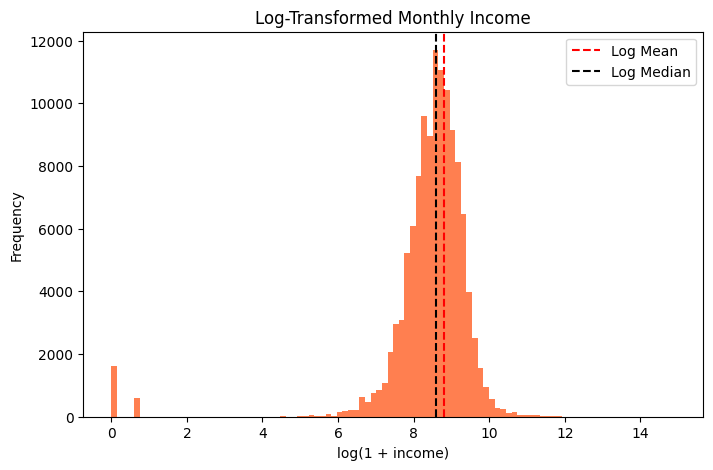

Normal default rate: 0.06964677038815795
Outlier default rate: 0.053082191780821915
MonthlyIncome
False    0.069486
True     0.056137
Name: SeriousDlqin2yrs, dtype: float64


,0
NumberOfDependents,0.02616
SeriousDlqin2yrs,0.00000
age,0.00000
RevolvingUtilizationOfUnsecuredLines,0.00000
NumberOfTime30-59DaysPastDueNotWorse,0.00000
DebtRatio,0.00000
NumberOfOpenCreditLinesAndLoans,0.00000
MonthlyIncome,0.00000
NumberOfTimes90DaysLate,0.00000
NumberRealEstateLoansOrLines,0.00000


In [150]:
mean_val = df_train["MonthlyIncome"].mean()
median_val = df_train["MonthlyIncome"].median()

print("Skew:", df_train["MonthlyIncome"].skew())
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df_train["MonthlyIncome"]), bins=100, color='coral')
plt.axvline(np.log1p(mean_val), color='red', linestyle='dashed', label="Log Mean")
plt.axvline(np.log1p(median_val), color='black', linestyle='dashed', label="Log Median")
plt.legend()
plt.title("Log-Transformed Monthly Income")
plt.xlabel("log(1 + income)")
plt.ylabel("Frequency")
plt.show()


threshold = df_train["MonthlyIncome"].quantile(0.99)
outliers = df_train[df_train["MonthlyIncome"] > threshold]
normal = df_train[df_train["MonthlyIncome"] <= threshold]
outliers = df_train[df_train["MonthlyIncome"] > threshold]

print("Normal default rate:", normal["SeriousDlqin2yrs"].mean())
print("Outlier default rate:", outliers["SeriousDlqin2yrs"].mean())
outliers.head(10)


print(df_train.groupby(df_train["MonthlyIncome"].isnull())["SeriousDlqin2yrs"].mean())

df_train["MonthlyIncome_missing"] = df_train["MonthlyIncome"].isnull().astype(int)
df_train["MonthlyIncome"] = df_train["MonthlyIncome"].fillna(df_train["MonthlyIncome"].median())

df_train.isnull().mean().sort_values(ascending=False)

**Number of Dependents Analysis**
- NOD is heavily right-skewed (1.588) with a heavy mass at 0, indicating the majority of borrowers had no dependents.
- The decision to use Median (0) as the imputed value was justified because:
  - NOD is a discrete variable, making the mean inappropriate as an imputed value (ex: a household cannot have 0.757 dependents). This makes median the most appropriate choice for the imputed value.
  - The median is robust towards the extreme right tail of the distribution, which would inflate the mean beyond what is representative of the typical borrower.
- NOD exhibits a generally increasing relationship with default risk for values between 0 and 4 dependents. For higher values, the sample sizes become extremely small (as few as 1-5 records at 13 and 20 dependents), resulting in unstable default rate estimates.
- Records with reported NOD defaulted 6.74% of the time compared to 4.56% of records with missing NOD values. This again indicates the potential for missingness to contain predictive information, so the status was preserved in a Dependents_missing variable.

Mean: 0.7572222678605657
Median: 0.0
Skew: 1.5882423788858833


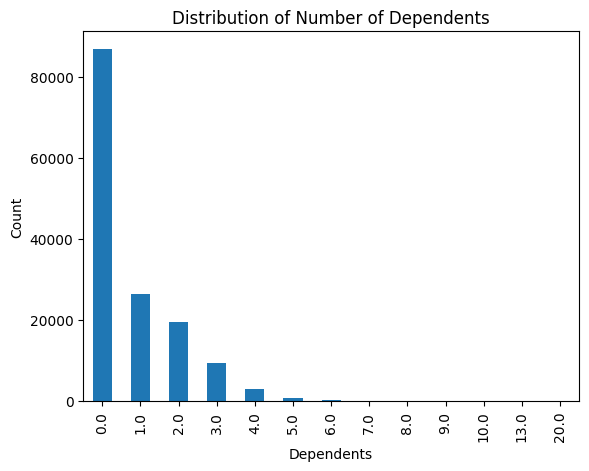

NumberOfDependents
False    0.067410
True     0.045617
Name: SeriousDlqin2yrs, dtype: float64


,0
SeriousDlqin2yrs,0.0
RevolvingUtilizationOfUnsecuredLines,0.0
age,0.0
NumberOfTime30-59DaysPastDueNotWorse,0.0
DebtRatio,0.0
MonthlyIncome,0.0
NumberOfOpenCreditLinesAndLoans,0.0
NumberOfTimes90DaysLate,0.0
NumberRealEstateLoansOrLines,0.0
NumberOfTime60-89DaysPastDueNotWorse,0.0


In [151]:
print("Mean:", df_train['NumberOfDependents'].mean())
print("Median:", df_train['NumberOfDependents'].median())
print("Skew:", df_train["NumberOfDependents"].skew())

df_train["NumberOfDependents"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Number of Dependents")
plt.xlabel("Dependents")
plt.ylabel("Count")
plt.show()


print(df_train.groupby(df_train["NumberOfDependents"].isnull())["SeriousDlqin2yrs"].mean())
summary = df_train.groupby("NumberOfDependents")["SeriousDlqin2yrs"].agg(
    default_rate="mean",
    count="count")
summary


df_train["Dependents_missing"] = df_train["NumberOfDependents"].isnull().astype(int)
df_train["NumberOfDependents"] = df_train["NumberOfDependents"].fillna(
    df_train["NumberOfDependents"].median())
df_train.isnull().mean().sort_values(ascending=False)

**Age Analysis**
- One record with age = 0 was identified and removed. Edge cases such as authorized user accounts were considered, but the presence of 2 real estate loans and 2 dependents confirms this was a data entry error rather than valid borrower profile. Removal has no meaningful impact on model training. Additionally, verified that all other ages were appropriate, with the second lowest at 21 being a valid borrowing age.

In [152]:
print("Records with an Age of 0 before removal:", df_train[df_train['age'] == 0].shape[0])
print("Records with an Age < 21 before removal:", df_train[df_train['age'] < 21].shape[0])

print(df_train[df_train['age'] == 0].head(10))

df_train = df_train[df_train['age'] != 0]
print("Records with an Age of 0 after removal:", df_train[df_train['age'] == 0].shape[0])

Records with an Age of 0 before removal: 1
Records with an Age < 21 before removal: 1
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
65695                 0                                   1.0    0   

       NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
65695                                     1   0.436927         6000.0   

       NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
65695                                6                        0   

       NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  \
65695                             2                                     0   

       NumberOfDependents  MonthlyIncome_missing  Dependents_missing  
65695                 2.0                      0                   0  
Records with an Age of 0 after removal: 0


**Debt Ratio Analysis**

- DebtRatio exhibits extreme right skew with a maximum value of 329,664 and mean of 353 compared to the median of 0.3665. This confirms a small number of extreme values are driving the distribution.
  - The analysis suggests many extreme debt ratios are associated with zero reported income because income appears in the denominator. These borrowers default at 4.04% despite having large debt ratios. The median debt ratio for a zero income borrower is 930 compared to 0.36 for all other borrowers, confirming extreme values are due to zero income in the denominator rather than real measures of debt burden.
- 23.42% (35,137) of borrowers have debt ratios greater than 1, meaning their monthly debt obligations exceeded their reported monthly income. These values are retained as plausible, as a debt ratio greater than 1 can be achieved through asset liquidation or temporary income disruption.
- Borrowers with a debt ratio above 1 default at a lower rate (6.52%) than those below 1 (6.73%). This suggests extreme debt ratio values may be driven by data quality issues rather than true high-risk behavior.
- DebtRatio is asymmetrically winsorized at the 99th percentile (4979.08), which affects 1,500 records (1% of the dataset). This reduces coefficient instability while retaining information from unusually high debt ratios. The jump from the 99th percentile (4,979) to the 99.9th percentile (10,613) to the maximum (329,664) confirms that a small number of extreme outliers are disproportionately driving the upper tail, making the 99th percentile an appropriate cutoff.


In [153]:
print(df_train["DebtRatio"].describe())
print(f"Records with a Debt Ratio > 1: {df_train[df_train['DebtRatio'] > 1].shape[0]}")
print(f"Percent of Borrowers with a Debt Ratio > 1: {df_train[df_train['DebtRatio'] > 1].shape[0]/len(df_train):.2%}")
print(f"Default rate for a Debt Ratio > 1: {df_train[df_train['DebtRatio'] > 1]['SeriousDlqin2yrs'].mean():.2%}")
print(f"Default rate for a Debt Ratio <= 1: {df_train[df_train['DebtRatio'] <= 1]['SeriousDlqin2yrs'].mean():.2%}")
print(f"Records with zero monthly income: {df_train[df_train['MonthlyIncome'] == 0].shape[0]}")
print(f"Default rate for zero income borrowers: {df_train[df_train['MonthlyIncome'] == 0]['SeriousDlqin2yrs'].mean():.2%}")
print(f"Median debt ratio for zero income borrowers: {df_train[df_train['MonthlyIncome'] == 0]['DebtRatio'].median():.2f}")
print(f"Median debt ratio for non-zero income borrowers: {df_train[df_train['MonthlyIncome'] != 0]['DebtRatio'].median():.2f}")

cap_99 = df_train['DebtRatio'].quantile(0.99)
df_train = df_train.copy()
df_train['DebtRatio_capped'] = df_train['DebtRatio'].clip(upper=cap_99)
print(f"Debt ratio capped at: {cap_99:.2f}")
print(f"Records affected by cap: {df_train[df_train['DebtRatio'] > cap_99].shape[0]}")
print(df_train["DebtRatio"].quantile([0.95, 0.99, 0.999]))

count    149999.000000
mean        353.007426
std        2037.825113
min           0.000000
25%           0.175074
50%           0.366503
75%           0.868257
max      329664.000000
Name: DebtRatio, dtype: float64
Records with a Debt Ratio > 1: 35137
Percent of Borrowers with a Debt Ratio > 1: 23.42%
Default rate for a Debt Ratio > 1: 6.52%
Default rate for a Debt Ratio <= 1: 6.73%
Records with zero monthly income: 1634
Default rate for zero income borrowers: 4.04%
Median debt ratio for zero income borrowers: 930.00
Median debt ratio for non-zero income borrowers: 0.36
Debt ratio capped at: 4979.08
Records affected by cap: 1500
0.950     2449.000
0.990     4979.080
0.999    10613.148
Name: DebtRatio, dtype: float64


**Income Quality Analysis**
Monthly Income is divided into three distinct groups:
  1. Clean: Reports that documented a monthly income greater than 0.
  2. Originally Missing: Reports that did not include a monthly income in the original dataset.
  3. Zero Income: Reports that documented a monthly income of 0.

- The clean group defaulted at the highest rate (6.9887%) compared to the originally missing (5.61%) and zero income (4.04%) groups.
  - Even though the zero income group had the lowest default rate, they also had the highest median debt ratio at 930 compared to non-zero income borrowers at 0.36. This confirms that the high debt ratio outliers are due to zero income in the denominator rather than actual financial distress.
  - Although the clean group had the highest default rate, they also had the lowest 90-day late count (0.208).

- The zero income group had the lowest median age at 47. This pushes back against the idea that the zero income group consists of retirees drawing a pension or 401(k).

   

In [154]:
df_train['income_quality'] = 'Clean'
df_train.loc[df_train['MonthlyIncome_missing'] == 1, 'income_quality'] = 'Originally Missing'
df_train.loc[df_train['MonthlyIncome'] == 0, 'income_quality'] = 'Zero Income'

print(df_train.groupby('income_quality')['SeriousDlqin2yrs'].agg(['mean', 'count']))

summary = df_train.groupby("income_quality").agg(
    default_rate=("SeriousDlqin2yrs", "mean"),
    count=("SeriousDlqin2yrs", "count"),
    mean_utilization=("RevolvingUtilizationOfUnsecuredLines", "mean"),
    median_utilization=("RevolvingUtilizationOfUnsecuredLines", "median"),
    mean_open_credit=("NumberOfOpenCreditLinesAndLoans", "mean"),
    median_open_credit=("NumberOfOpenCreditLinesAndLoans", "median"),
    median_90_days_late=("NumberOfTimes90DaysLate", "median"),
    mean_90_dates_late=("NumberOfTimes90DaysLate", "median"),
    mean_age=("age", "mean"),
    median_age=("age", "median")
)

summary

                        mean   count
income_quality                      
Clean               0.069887  118634
Originally Missing  0.056137   29731
Zero Income         0.040392    1634


,default_rate,count,mean_utilization,median_utilization,mean_open_credit,median_open_credit,median_90_days_late,mean_90_dates_late,mean_age,median_age
income_quality,,,,,,,,,,
Clean,0.069887,118634,5.922005,0.178151,8.781867,8.0,0.0,0.0,51.330892,51.0
Originally Missing,0.056137,29731,6.649421,0.081697,7.216071,6.0,0.0,0.0,56.362349,57.0
Zero Income,0.040392,1634,4.295944,0.109118,7.061812,6.0,0.0,0.0,48.337209,47.0


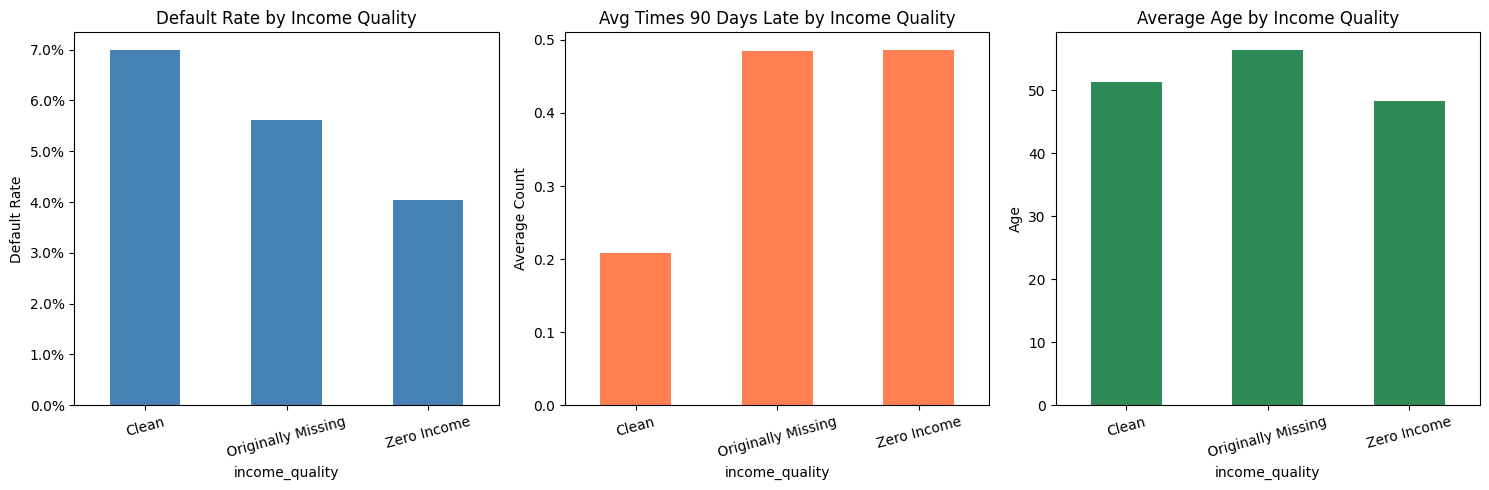

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
default_rates = df_train.groupby('income_quality')['SeriousDlqin2yrs'].mean()


default_rates.plot(kind='bar', ax=axes[0], color='steelblue', rot=15)
axes[0].set_title('Default Rate by Income Quality')
axes[0].set_ylabel('Default Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

late_rates = df_train.groupby('income_quality')['NumberOfTimes90DaysLate'].mean()

late_rates.plot(kind='bar', ax=axes[1], color='coral', rot=15)
axes[1].set_title('Avg Times 90 Days Late by Income Quality')
axes[1].set_ylabel('Average Count')

age_means = df_train.groupby('income_quality')['age'].mean()

age_means.plot(kind='bar', ax=axes[2], color='seagreen', rot=15)
axes[2].set_title('Average Age by Income Quality')
axes[2].set_ylabel('Age')

plt.tight_layout()
plt.show()

# Section 3: Logistic Regression


Logistic regression was used as the baseline because of it's ability to determine the probability of a default.

According to the target variable, 93.316% of borrowers paid their loans on time, compared to 6.684% of borrowers who did not pay in time. This confirms a severe class imbalance, which was mitigated through balancing classes to ensure the model was harshly penalized for a false negative.

In [156]:
features = [
    'RevolvingUtilizationOfUnsecuredLines','age','NumberOfTime30-59DaysPastDueNotWorse','DebtRatio_capped','MonthlyIncome','NumberOfOpenCreditLinesAndLoans','NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines','NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents','MonthlyIncome_missing','Dependents_missing']
X = df_train[features]
y = df_train['SeriousDlqin2yrs']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:{y.value_counts(normalize=True)}")

Feature matrix shape: (149999, 12)
Target distribution:SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


The X and y variables were split into two groups: 80% for training and 20% for testing.

Stratify y ensures that the severe class imbalance is preserved in both groups.

Random state guarantees the results are reproducible.

In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=33,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")

Training set size: 119999
Test set size: 30000
Training default rate: 6.68%
Test default rate: 6.68%


For this section, I used feature scaling via StandardScaler to standardize the variables, forcing them onto the same scale with a center at 0 and standard deviation of 1. This allows for the comparison of variables that have different scales, which is especially important when analyzing feature importance. The test set uses the same mean and standard deviations calculated from the training set to prevent data leakage.

In [158]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

**Model Metrics**
- The model successfully identified 66% of all actual defaults in the test set.
  - An F1 of 0.28 and a 66% recall indicates that the model is prioritizing catching defaults over being precise, which generates a larger amount of false positives.
- The model successfully identified 78% of the borrowers who did not default in the test set.
  - An F1 of 0.86 and a recall of 78% shows that the model is stable when handling non-default borrowers and does not produce an extreme amount of false positives or negatives.

- Recall is prioritized in this situation, because the loss resulting from a False negative is exponentially higher than the cost of a false positive.

- With largely imbalanced classes, Accuracy is not a good indicator of model functions. A model that always predicts negative would reach a 93% accuracy rate in this scenario because only 6% of the data belongs to the other class.


In [159]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=33,
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.78      0.86     27995
           1       0.18      0.66      0.28      2005

    accuracy                           0.77     30000
   macro avg       0.57      0.72      0.57     30000
weighted avg       0.92      0.77      0.83     30000



**Feature Importance:**

For every one-standard-deviation increase in the number of times a borrower is 30-59 days past due, the log-odds of defaulting rise by 2.19, holding all other variables constant.
  - 60-89 days past due adds very little log-odds (0.22673) because the alarm was already sounded by the initial late flag.
  - 90 days past due spikes back up because it counts how many times the borrower has already broken the 90 day barrier.

For every one-standard-deviation increase in a borrower’s age, the log-odds of defaulting decrease by 0.44, holding all other variables constant.

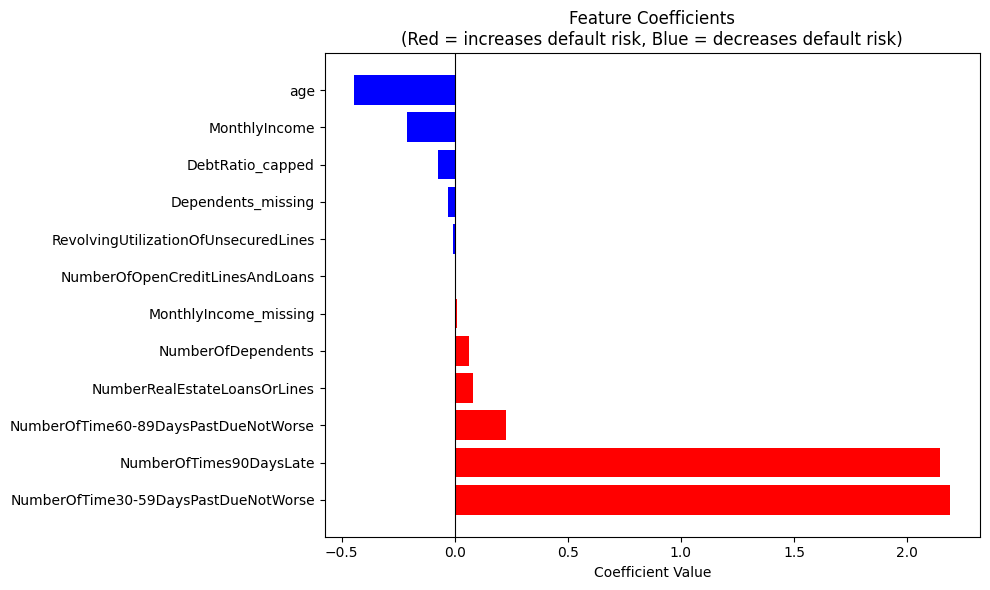

                             Feature  Coefficient
NumberOfTime30-59DaysPastDueNotWorse     2.190453
             NumberOfTimes90DaysLate     2.143569
NumberOfTime60-89DaysPastDueNotWorse     0.226730
        NumberRealEstateLoansOrLines     0.080445
                  NumberOfDependents     0.062682
               MonthlyIncome_missing     0.009346
     NumberOfOpenCreditLinesAndLoans     0.005703
RevolvingUtilizationOfUnsecuredLines    -0.005314
                  Dependents_missing    -0.030465
                    DebtRatio_capped    -0.072141
                       MonthlyIncome    -0.210973
                                 age    -0.443433


In [160]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if c > 0 else 'blue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients\n(Red = increases default risk, Blue = decreases default risk)')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

Our model correctly classified 21,837 True negative borrowers who did not default and were not predicted to default. However, 6,158 borrowers that did not default were predicted to default by the model, approximately 22% of all borrowers who did not default. The model inaccurately identified 681 borrowers as unlikely to default who then went onto default, compared to 1,324 they identified as likely to default and who did default. Among the group of borrowers who defaulted, 33.97% were false negatives. This model is simultaneously too strict with good borrowers and too lenient with ones likely to default, representing the inherent danger of solely relying on baseline logistic framework. As discussed earlier, avoiding losses matters much more than determining the good borrowers. In this situation, a 33.97% false negative rate represents a serious financial danger.

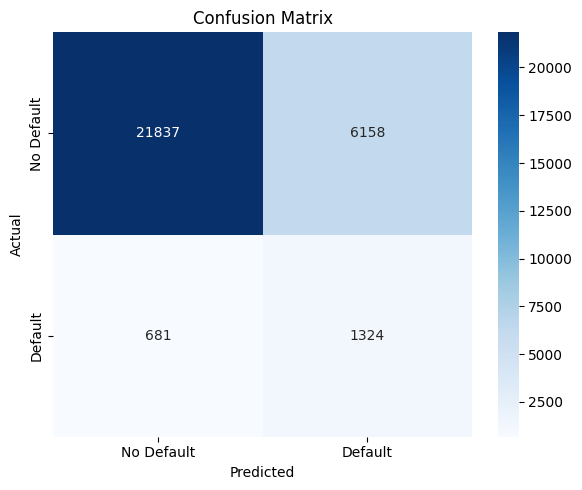

True Negatives:  21,837
False Positives: 6,158
False Negatives: 681
True Positives:  1,324
False Negative Rate: 33.97%
False Positive Rate: 22.00%


In [161]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")
print(f"False Negative Rate: {fn/(fn+tp):.2%}")
print(f"False Positive Rate: {fp/(fp+tn):.2%}")

- Because the model was trained under an artificial assumption that both groups occur with equal frequency, the average predicted probability is inflated. This will need to be mitigated in the future.

- The clean group had the highest actual default rate (6.93%) and the second highest predicted default rate (42.76%). Although the Originally missing group had the second highest default rate (5.77%), they also had the lowest predicted default rate (35.29%). The ranking was flipped with the Zero Income group, who had the lowest default rate (4.68%) and the highest predicted default rate (45.01%)

- Both the Clean and Originally Missing groups demonstrate a similar inflation factor (6.17 and 6.12 respectively). However, the inflation factor for the zero income group rises to 9.62, showing that the model systematically over penalizes borrowers with zero income.

- The clean group has solid discriminatory power (0.7917) and a high ability to target actual defaults without throwing excessive false positives. The PR-AUC of 0.3125 is approximately 4.5x larger than the baseline default rate of 6.93%, showing that the model is 4.5x better at predicting actual defaults rather than random guessing. This ratio is greater for both the Originally missing and Zero Income groups (5.842x and 5.459x, respectively).


Clean:
  Count: 23,853
  Actual default rate: 6.93%
  Avg predicted probability: 42.76%
  ROC-AUC: 0.7917
  PR-AUC (Avg Precision): 0.3125

Originally Missing:
  Count: 5,805
  Actual default rate: 5.77%
  Avg predicted probability: 35.29%
  ROC-AUC: 0.8425
  PR-AUC (Avg Precision): 0.3371

Zero Income:
  Count: 342
  Actual default rate: 4.68%
  Avg predicted probability: 45.01%
  ROC-AUC: 0.8523
  PR-AUC (Avg Precision): 0.2555


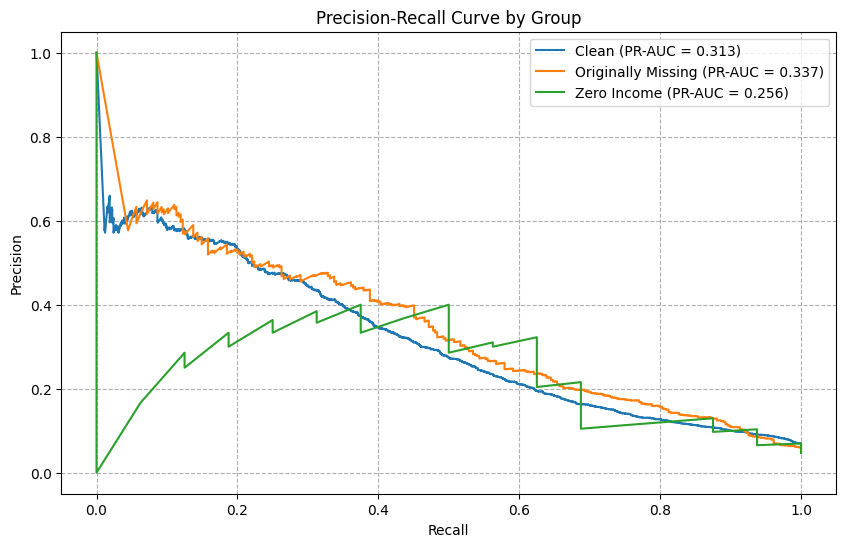

In [162]:
test_indices = X_test.index
df_test_eval = df_train.loc[test_indices].copy()
df_test_eval['predicted_prob'] = y_prob
df_test_eval['predicted_default'] = y_pred

plt.figure(figsize=(10, 6))

for group in ['Clean', 'Originally Missing', 'Zero Income']:
    mask = df_test_eval['income_quality'] == group
    group_data = df_test_eval[mask]

    if len(group_data) > 0:
        group_auc = roc_auc_score(
            group_data['SeriousDlqin2yrs'],
            group_data['predicted_prob']
        )

        group_pr_auc = average_precision_score(
            group_data['SeriousDlqin2yrs'],
            group_data['predicted_prob']
        )

        precision, recall, thresholds = precision_recall_curve(
            group_data['SeriousDlqin2yrs'],
            group_data['predicted_prob']
        )

        actual_default = group_data['SeriousDlqin2yrs'].mean()
        predicted_default = group_data['predicted_prob'].mean()

        print(f"\n{group}:")
        print(f"  Count: {len(group_data):,}")
        print(f"  Actual default rate: {actual_default:.2%}")
        print(f"  Avg predicted probability: {predicted_default:.2%}")
        print(f"  ROC-AUC: {group_auc:.4f}")
        print(f"  PR-AUC (Avg Precision): {group_pr_auc:.4f}")
        plt.plot(recall, precision, label=f'{group} (PR-AUC = {group_pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve by Group')
plt.legend(loc='best')
plt.grid(True, linestyle='--')
plt.show()

**Gini Coefficient and KS Statistic:**

- A Gini Coefficient of 0.7046 means that the model has a higher concentration of risk-differentiation power than a random assignment model.
  - The Gini coefficient indicates good discriminatory power for ranking borrowers by default risk.
- The KS statistic of 0.5867 means that at the optimal separation point, the model successfully separates 58.67% of the true defaults away from the creditworthy borrowers.

In [163]:
group_gini = 2 * group_auc - 1

probs_defaults = group_data[group_data['SeriousDlqin2yrs'] == 1]['predicted_prob']
probs_safe = group_data[group_data['SeriousDlqin2yrs'] == 0]['predicted_prob']

ks_stat, _ = ks_2samp(probs_defaults, probs_safe)

print(f"Gini Coefficient: {group_gini:.4f}")
print(f"KS Statistic: {ks_stat:.4f}")

Gini Coefficient: 0.7046
KS Statistic: 0.5867


# Section 4: Random Forest

- The clean group had the highest actual default rate (6.93%) and the highest predicted default rate (36.04%). Similar to the logistic regression model, the originally missing group had the second highest actual default rate (5.77%), but the lowest predicted default rate (30.14%). This ordering was flipped with the zero income group, who had the lowest default rate (4.68%) and the second highest predicted default rate (35.33%). However, unlike in logistic regression, this predicted default rate did not change orders with the clean group, who ranked the highest.

- Both the Clean and Originally Missing groups demonstrate a similar inflation factor (5.201 and 5.224 respectively). However, the inflation factor for the zero income group again rises to 7.549, furthering the idea that the model systematically over penalizes borrowers with zero income.

- The clean group has solid discriminatory power (0.8545) and a high ability to target actual defaults without throwing excessive false positives. The PR-AUC of 0.3744 is approximately 5.4x larger than the baseline default rate of 6.93%, showing that the model is 5.4x better at predicting actual defaults rather than random guessing.  This ratio is greater for both the Originally missing and Zero Income groups (6.927x and 6.718x, respectively)

In [164]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=50,
    random_state=33,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print(f"Random Forest AUC: {roc_auc_score(y_test, rf_prob):.4f}")
print(classification_report(y_test, rf_pred))

df_test_eval['rf_predicted_prob'] = rf_prob

for group in ['Clean', 'Originally Missing', 'Zero Income']:
    mask = df_test_eval['income_quality'] == group
    group_data = df_test_eval[mask]

    if len(group_data) > 0:
        group_auc = roc_auc_score(
            group_data['SeriousDlqin2yrs'],
            group_data['rf_predicted_prob']
        )
        predicted_default = group_data['rf_predicted_prob'].mean()
        actual_default = group_data['SeriousDlqin2yrs'].mean()

        print(f"\n{group}:")
        print(f"  Actual default rate: {actual_default:.2%}")
        print(f"  Avg predicted probability: {predicted_default:.2%}")
        print(f"  ROC-AUC: {group_auc:.4f}")

Random Forest AUC: 0.8641
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.21      0.77      0.33      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.79      0.84     30000


Clean:
  Actual default rate: 6.93%
  Avg predicted probability: 36.04%
  ROC-AUC: 0.8545

Originally Missing:
  Actual default rate: 5.77%
  Avg predicted probability: 30.14%
  ROC-AUC: 0.8975

Zero Income:
  Actual default rate: 4.68%
  Avg predicted probability: 35.33%
  ROC-AUC: 0.9227


In [165]:
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

df_test_eval = df_train.loc[X_test.index].copy()
df_test_eval['predicted_prob'] = rf_prob
df_test_eval['predicted_default'] = rf_pred

for group in ['Clean', 'Originally Missing', 'Zero Income']:
    mask = df_test_eval['income_quality'] == group
    group_data = df_test_eval[mask]

    if len(group_data) > 0:
        group_auc = roc_auc_score(group_data['SeriousDlqin2yrs'], group_data['predicted_prob'])
        group_pr_auc = average_precision_score(group_data['SeriousDlqin2yrs'], group_data['predicted_prob'])

        print(f"{group} PR-AUC: {group_pr_auc:.4f}")

Clean PR-AUC: 0.3744
Originally Missing PR-AUC: 0.3997
Zero Income PR-AUC: 0.3144


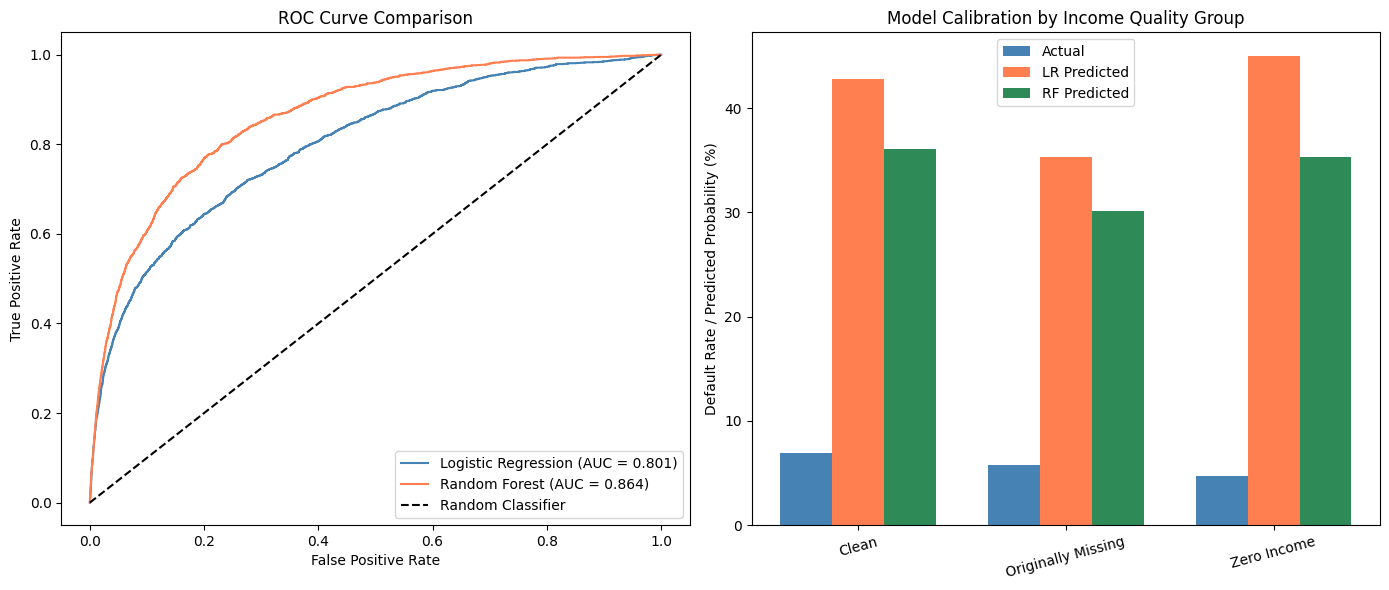

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

axes[0].plot(fpr_lr, tpr_lr, color='steelblue',
             label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='coral',
             label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

groups = ['Clean', 'Originally Missing', 'Zero Income']
actual_rates = [6.93, 5.77, 4.68]
lr_predicted = [42.76, 35.29, 45.01]
rf_predicted = [36.04, 30.14, 35.33]

x = range(len(groups))
width = 0.25

axes[1].bar([i - width for i in x], actual_rates, width,
            label='Actual', color='steelblue')
axes[1].bar([i for i in x], lr_predicted, width,
            label='LR Predicted', color='coral')
axes[1].bar([i + width for i in x], rf_predicted, width,
            label='RF Predicted', color='seagreen')

axes[1].set_xticks(x)
axes[1].set_xticklabels(groups, rotation=15)
axes[1].set_ylabel('Default Rate / Predicted Probability (%)')
axes[1].set_title('Model Calibration by Income Quality Group')
axes[1].legend()

plt.tight_layout()
plt.show()

The Kolmogorov-Smirnov (KS) statistic measures the maximum distance between the cumulative distribution of your defaults (bads) and non-defaults (goods). At the logistic regression's optimal cutoff, the model was able to separate 58.67% of the bads away from the goods. In this random forest model, the KS statistic decreases to 57, meaning 57% of the bads were separated from the goods. The 1.67 percentage points dropoff could be due to the possibility of overfitting introduced by the use of decision trees.

In [167]:
lr_pos = df_test_eval[df_test_eval['SeriousDlqin2yrs'] == 1]['predicted_prob']
lr_neg = df_test_eval[df_test_eval['SeriousDlqin2yrs'] == 0]['predicted_prob']

rf_pos = df_test_eval[df_test_eval['SeriousDlqin2yrs'] == 1]['predicted_prob']
rf_neg = df_test_eval[df_test_eval['SeriousDlqin2yrs'] == 0]['predicted_prob']

ks_rf, _ = ks_2samp(rf_pos, rf_neg)

print(f"Random Forest K-S Statistic: {ks_rf * 100:.2f}")

Random Forest K-S Statistic: 57.00
